# Assignment 1 — Linear Regression from Scratch
**AIMS Ghana — Machine Learning Course, 2025**
**Author:** Mawulikplimi Roland Hounkpe | `rhounkpe`

---

## Overview

In this assignment we implement **Simple Linear Regression** entirely from scratch using NumPy.

We find the optimal parameters $\theta = (\theta_0, \theta_1)$ using three approaches:

| Method | Description |
|---|---|
| **Analytical solution** | Set $\nabla_\theta \ell = 0$ and solve the system |
| **Normal Equation** | $\theta = (X^TX)^{-1}X^Ty$ |
| **Gradient Descent** | $\theta \leftarrow \theta - \alpha \nabla_\theta \ell$ |

The loss function is the **Mean Squared Error (MSE)**:
$$\ell(\theta) = \frac{1}{2m}\|X\theta - y\|_2^2$$


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')


## 2. Load and Visualise the Data

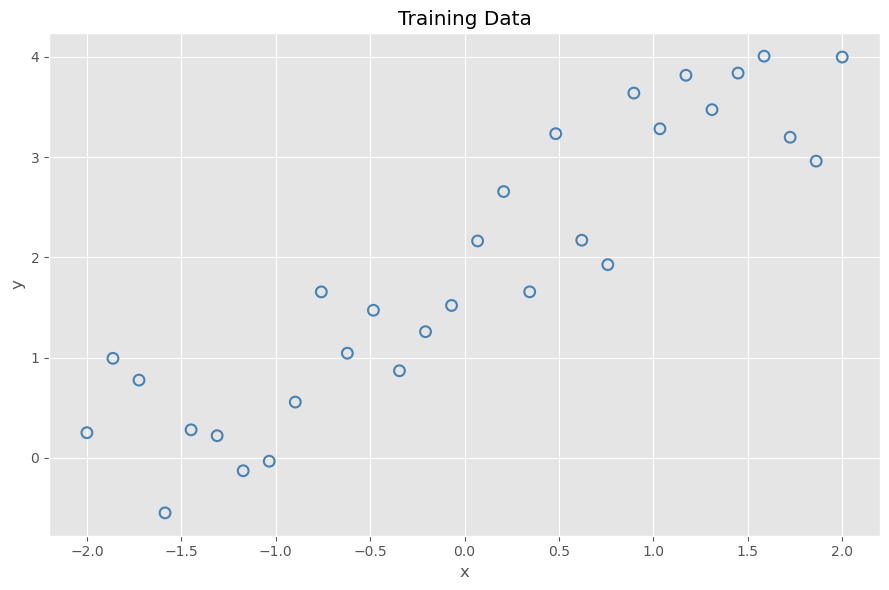

Dataset: 30 examples


In [4]:
data = np.loadtxt('data/linearReg.out')
x = data[:, 0]
y = data[:, 1]

plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=60, edgecolors='steelblue', facecolors='none', linewidths=1.5)
plt.xlabel('x'); plt.ylabel('y'); plt.title('Training Data')
plt.tight_layout(); plt.show()
print(f'Dataset: {len(x)} examples')


## 3. Analytical Solution — Setting $\nabla_\theta \ell = 0$

### Question 1

The MSE loss is:
$$\ell(\theta_0,\theta_1) = \frac{1}{m}\sum_{i=1}^{m}\left(y_i - \theta_0 - \theta_1 x_i\right)^2$$

Setting partial derivatives to zero and solving gives the closed-form solution:

$$\boxed{\theta_1 = \frac{\sum_{i=1}^{m}(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^{m}(x_i-\bar{x})^2}, \qquad \theta_0 = \bar{y} - \theta_1\bar{x}}$$


## 4. Normal Equation

### Question 2

Design matrix:
$$X = \begin{pmatrix} 1 & x_1 \\\\ 1 & x_2 \\\\ \vdots & \vdots \\\\ 1 & x_m \end{pmatrix} \qquad \Rightarrow \qquad \theta = (X^TX)^{-1}X^Ty$$


In [5]:
# Construct the design matrix [1, x]
X = np.c_[np.ones(len(data)), x]

# Solve the Normal Equation
opt_theta_normal = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
print('Optimal theta (Normal Equation):', opt_theta_normal)


Optimal theta (Normal Equation): [1.87270208 1.0559765 ]


## 5. Cost Function and Gradient Descent

### Question 3

**Cost:**
$$\ell(\theta) = \frac{1}{2m}\|X\theta - y\|_2^2$$

**Gradient:**
$$\nabla_\theta\ell = \frac{1}{m}X^T(X\theta - y)$$

**Update rule:**
$$\theta \leftarrow \theta - \alpha \cdot \nabla_\theta\ell(\theta)$$


In [6]:
def computeCost(X, y, theta):
    """
    Compute the MSE loss and its gradient.

    Parameters
    ----------
    X     : design matrix  (m × n)
    y     : target vector  (m,)
    theta : parameter vector (n,)

    Returns
    -------
    [loss, grad]
    """
    n_sample = len(y)
    loss = 1 / (2 * n_sample) * np.sum((X.dot(theta) - y) ** 2)
    grad = 1 / n_sample * (X.T.dot(X.dot(theta) - y))
    return [loss, grad]

# Initialise theta to zero and check the initial loss
theta = np.zeros(X.shape[1])
print('Initial loss:', computeCost(X, y, theta)[0], '\t(expected ≈ 2.7 on original dataset)')


Initial loss: 2.7120845489549867 	(expected ≈ 2.7 on original dataset)


In [7]:
def gradientDescent(X, y, theta, eta, num_iters):
    """
    Run gradient descent for linear regression.

    Parameters
    ----------
    X         : design matrix
    y         : target vector
    theta     : initial parameter vector
    eta       : learning rate
    num_iters : number of iterations

    Returns
    -------
    [theta, lossVals, thetaVals]
    """
    lossVals  = []
    thetaVals = []
    for i in range(num_iters):
        thetaVals.append(theta.copy())
        loss, grad = computeCost(X, y, theta)
        theta = theta - eta * grad       # gradient descent update
        lossVals.append(loss)
    return [theta, lossVals, thetaVals]

eta       = 0.02
num_iters = 400

opt_theta_GD, loss_history, theta_history = gradientDescent(X, y, theta, eta, num_iters)
print('Optimal theta (Gradient Descent) :', opt_theta_GD)
print('Optimal theta (Normal Equation)  :', opt_theta_normal)
print('\n✓ Both methods should agree closely.')


Optimal theta (Gradient Descent) : [1.87212279 1.0559665 ]
Optimal theta (Normal Equation)  : [1.87270208 1.0559765 ]

✓ Both methods should agree closely.


### Convergence of the Loss

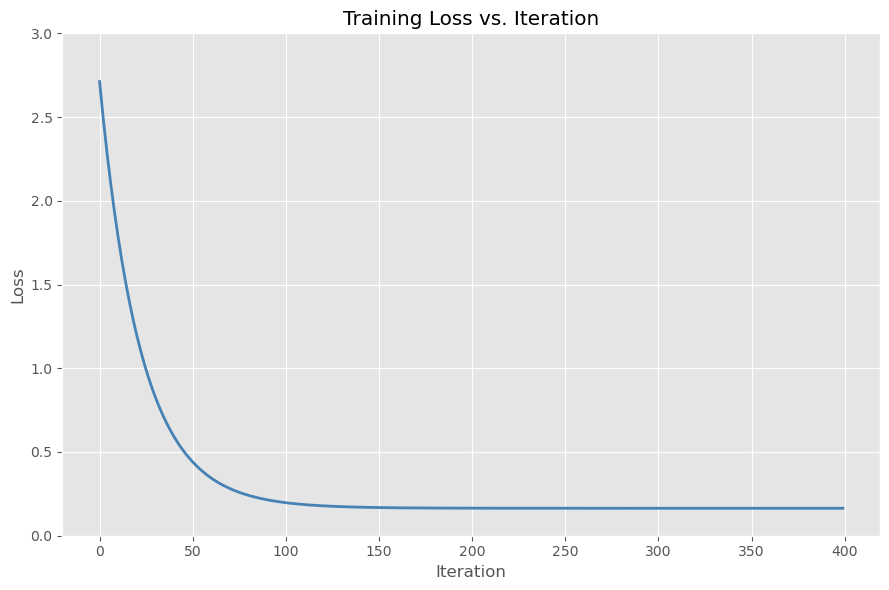

In [9]:
plt.figure(figsize=(9, 6))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.ylim((0, 3)); plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('Training Loss vs. Iteration'); plt.tight_layout(); plt.show()


### Fitted Model

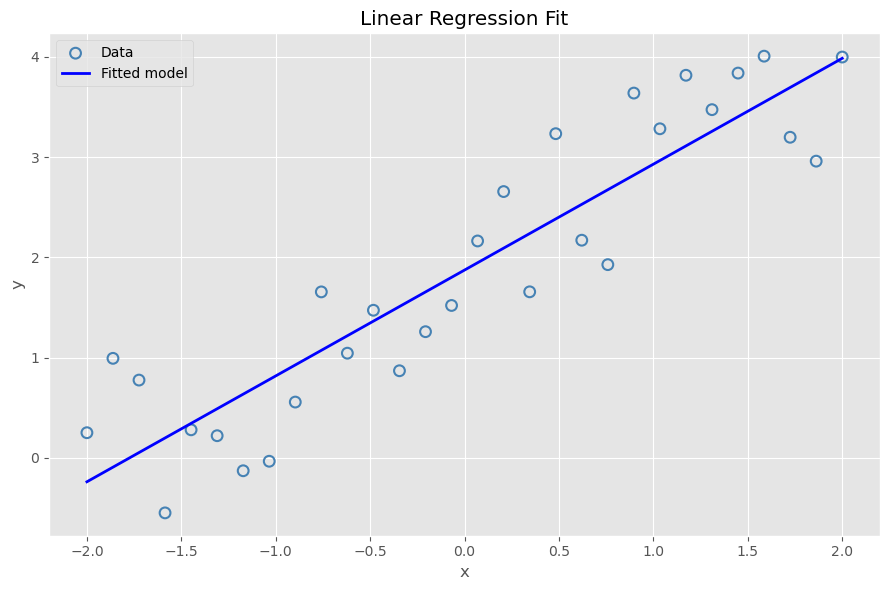

In [11]:
xi_plot = np.linspace(np.min(data[:,0]), np.max(data[:,0]), 100)
X_plot  = np.c_[np.ones(100), xi_plot]
model   = X_plot.dot(opt_theta_normal)

plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=60, edgecolors='steelblue', facecolors='none', linewidths=1.5, label='Data')
plt.plot(xi_plot, model, 'b-', linewidth=2, label='Fitted model')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Linear Regression Fit')
plt.legend(); plt.tight_layout(); plt.show()


## 6. Prediction on New Data

In [12]:
unseen_x = np.array([[1, 2.5], [1, 3]])
predict  = unseen_x.dot(opt_theta_normal)
print('Predictions:', predict)


Predictions: [4.51264332 5.04063157]


## 7. Effect of the Learning Rate

- **$\eta$ too large** → loss may diverge (e.g. $\eta = 2$)
- **$\eta$ too small** → very slow convergence
- **$\eta$ optimal** → smooth, fast convergence


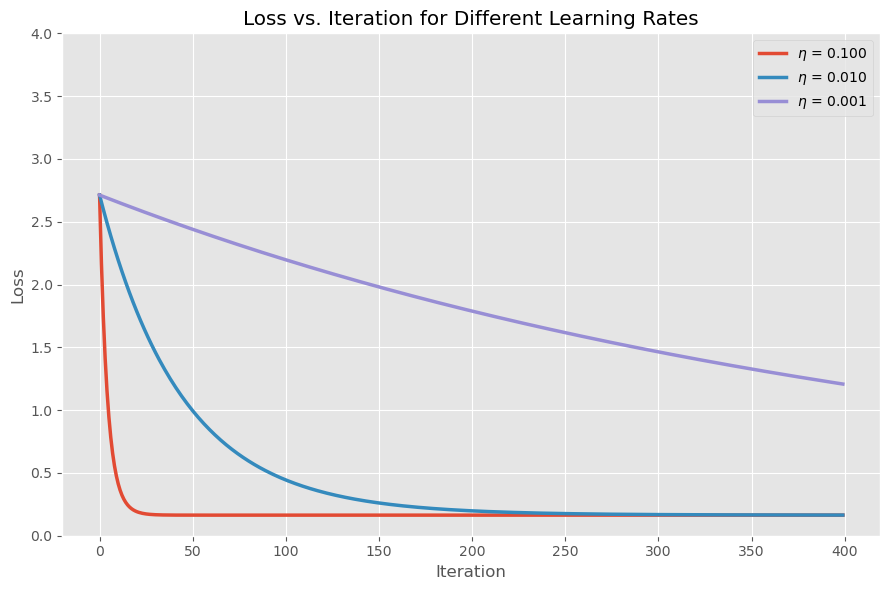

In [15]:
theta_list = [0.100, 0.010, 0.001]
plt.figure(figsize=(9, 6))
for eta_val in theta_list:
    theta0 = np.zeros(X.shape[1])
    _, lh, _ = gradientDescent(X, y, theta0, eta_val, num_iters)
    plt.plot(lh, linewidth=2.5, label=f'$\\eta$ = {eta_val:.3f}')
plt.legend(); plt.ylim((0, 4))
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('Loss vs. Iteration for Different Learning Rates')
plt.tight_layout(); plt.show()


**Observation:**
- $\eta = 0.100$ → converges quickly (~50 iterations)
- $\eta = 0.010$ → converges moderately
- $\eta = 0.001$ → still far from optimal after 400 iterations
- $\eta = 2$ (not plotted) → **diverges** — the step overshoots the minimum


## 8. Loss Surface Visualisation

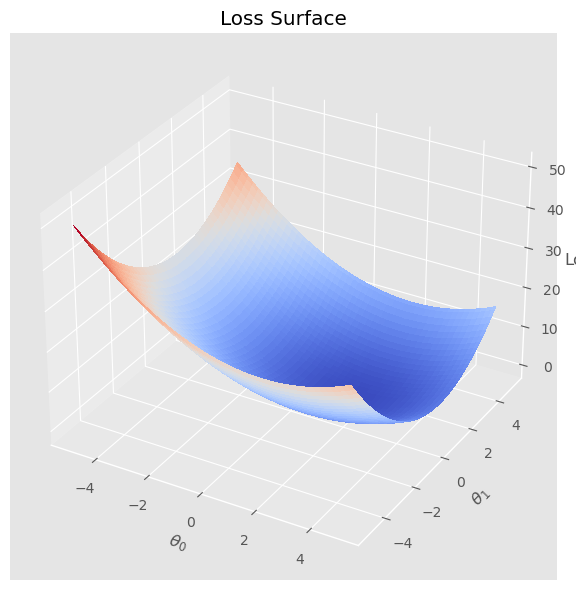

In [17]:
from matplotlib import cm

npoints = 100
w0 = np.linspace(-5, 5, npoints)
w1 = np.linspace(-5, 5, npoints)
W0, W1 = np.meshgrid(w0, w1)

cost_vals = np.empty((npoints, npoints))
for i in range(npoints):
    cost_vals[i] = [computeCost(X, y, np.array(w))[0] for w in zip(W0[i], W1[i])]

# 3-D surface
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(9, 6))
ax.plot_surface(W0, W1, cost_vals, cmap=cm.coolwarm, linewidth=0.5, antialiased=False)
ax.scatter(opt_theta_normal[0], opt_theta_normal[1],
           computeCost(X, y, opt_theta_normal)[0],
           color='red', s=80, zorder=5)
ax.set_xlabel(r'$\theta_0$'); ax.set_ylabel(r'$\theta_1$'); ax.set_zlabel('Loss')
ax.set_title('Loss Surface'); plt.tight_layout(); plt.show()


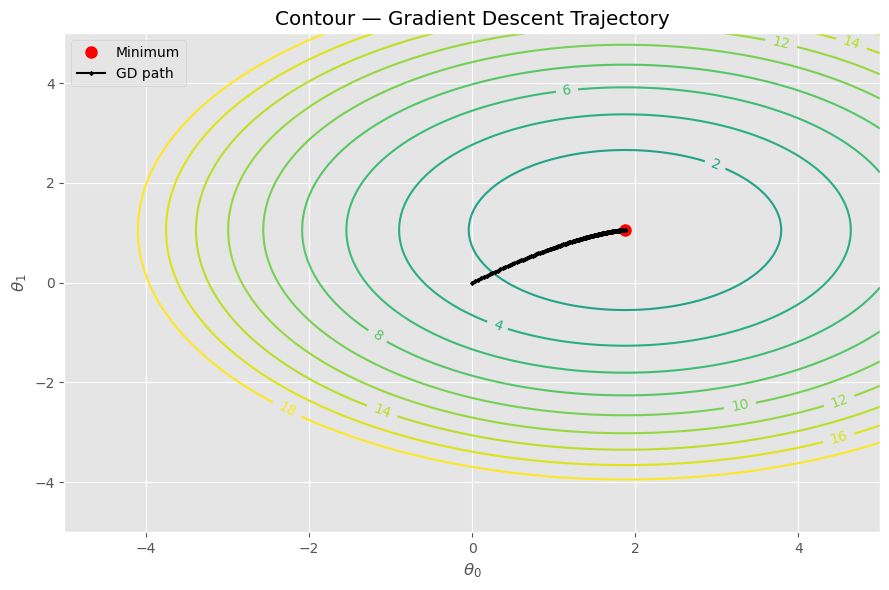

In [18]:
# Contour plot with gradient descent trajectory
w_hist = np.array(theta_history)

fig2, ax2 = plt.subplots(figsize=(9, 6))
CS = ax2.contour(W0, W1, cost_vals, np.arange(-20, 20, 2))
ax2.plot(opt_theta_normal[0], opt_theta_normal[1], 'ro', markersize=8, label='Minimum')
ax2.plot(w_hist[:, 0], w_hist[:, 1], 'kx-', markersize=2, mew=2, label='GD path')
plt.clabel(CS, inline=1, fontsize=10)
ax2.set_xlabel(r'$\theta_0$'); ax2.set_ylabel(r'$\theta_1$')
ax2.set_title('Contour — Gradient Descent Trajectory')
ax2.legend(); plt.tight_layout(); plt.show()


## 9. (Optional) Feature Normalisation — Olympic Dataset

When features have very large values (e.g. years 1896–2012), gradients explode and gradient descent **diverges**.

**Standardisation** rescales each feature:
$$x^{\text{std}}_i = \frac{x_i - \mu}{\sigma}$$


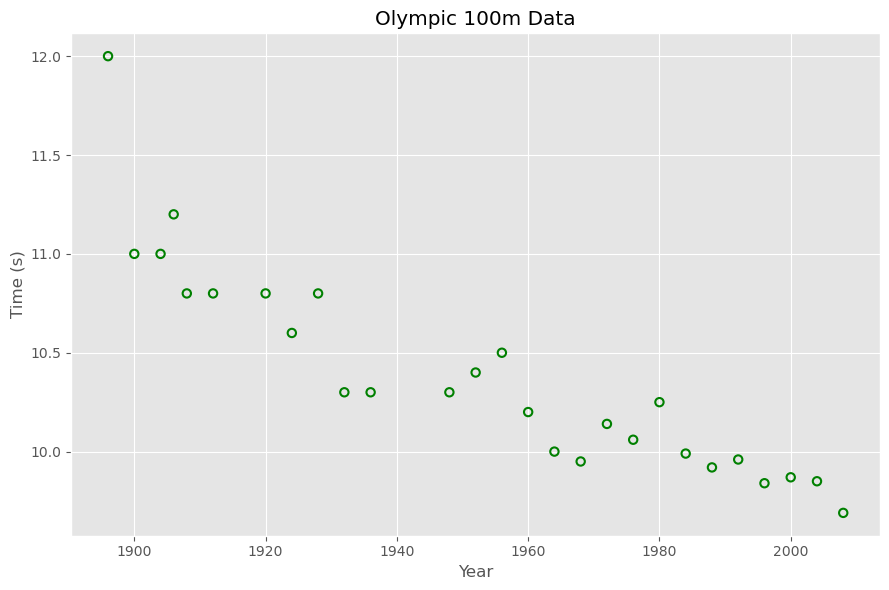

Feature range: [1896, 2008] → very large → GD diverges without normalisation


In [20]:
olympic_data = np.loadtxt('data/olympic.txt', delimiter=',')
x_o = olympic_data[:, 0]
y_o = olympic_data[:, 1]

plt.figure(figsize=(9, 6))
plt.scatter(x_o, y_o, edgecolors='green', facecolors='none', linewidths=1.5)
plt.xlabel('Year'); plt.ylabel('Time (s)'); plt.title('Olympic 100m Data')
plt.tight_layout(); plt.show()
print(f'Feature range: [{x_o.min():.0f}, {x_o.max():.0f}] → very large → GD diverges without normalisation')


In [21]:
# Standardise the feature
x_st = (x_o - np.mean(x_o)) / np.std(x_o)
X1   = np.c_[np.ones(len(x_o)), x_st]

theta1 = np.zeros(X1.shape[1])
eta    = 0.1
opt_theta_olympic, lh_olympic, _ = gradientDescent(X1, y_o, theta1, eta, num_iters)

print('Optimal theta (Olympic, standardised):', opt_theta_olympic)
print('Expected result                       :', np.array([10.38962963, -0.46667477]))


Optimal theta (Olympic, standardised): [10.38962963 -0.46667477]
Expected result                       : [10.38962963 -0.46667477]


**Key takeaway:** Always normalise or standardise features before running gradient descent, especially when different features live on very different scales.